# **OSEMN: Model | Modelling**

The models used are:
1. Multiple Linear Regression (MLR)
2. Classification Model
3. Ridge and Lasso Regression
4. Decision Tree

Target variable: **yield_rate**



**1. Environment Setup: Mount Drive to Upload in Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**2. Library Import and Dataset Loading**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#import modules for model selection and evaluation from scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    r2_score, mean_squared_error,
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    precision_score, recall_score
)

#import machine learning models from scikit-learn
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text


#import utilities for building pipelines and preprocessing data
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

#import statsmodels for R² and adjusted R² calculations
import statsmodels.api as sm

#show float numbers with 4 decimal places
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

#dataset
df = pd.read_excel('/content/drive/MyDrive/P2 MDS/03_Data_Preprocessing/final_dataset_feature_engineered.xlsx')

#check number of rows and columns
print(df.shape)
print(df.columns.tolist())

(276, 52)
['unitid', 'institution_name', 'year', 'level_of_student', 'enrollment_men', 'enrollment_women', 'idx_ef', 'enrollment_asian', 'enrollment_black', 'enrollment_hispanic', 'enrollment_white', 'enrollment_international', 'idx_gr', 'applicants_total', 'applicants_men', 'applicants_women', 'admissions_total', 'admissions_men', 'admissions_women', 'enrolled_total', 'enrolled_men', 'enrolled_women', 'sat_submission_rate', 'act_submission_rate', 'sat_rw', 'sat_math_75th', 'act_75th', 'drvef_full-time_enrollment', 'enrollment_undergrad', 'enrollment_grad', 'institution_control', 'urbanization', 'carnegie_classification', 'student_faculty_ratio', 'aid_any_percent', 'sfa_pell_grant', 'aid_avg_amount', 'grad_men_completers', 'grad_total_completers', 'grad_women_completers', 'retention_rate', 'admission_rate', 'yield_rate', 'conversion_rate', 'gender_balance', 'intl_share', 'faculty_student_ratio', 'grad_share', 'aid_coverage', 'pell_share', 'intl_composition', 'grad_composition']


**3. Define Target and Features**

The primary target variable is **yield_rate**.  
The predictor variables are selected institutional characteristics.

In [ ]:
#define variables
target_variable = "yield_rate"
year_col = "year"

features = [
    "admission_rate",
    "intl_composition",
    "faculty_student_ratio",
    "grad_composition",
    "aid_coverage",
    "pell_share",
    "retention_rate"
]

model_df = df[[year_col] + features + [target_variable]].dropna().copy()

print("Modelling dataset shape:", model_df.shape)
print("Target variable:", target_variable)
print("Features used:", features)

Modelling dataset shape: (271, 9)
Target variable: yield_rate
Features used: ['admission_rate', 'intl_composition', 'faculty_student_ratio', 'grad_composition', 'aid_coverage', 'pell_share', 'retention_rate']


**4. Train-Test Split**

The dataset is divided into training and testing sets using an 80:20 ratio.

In [ ]:
X = model_df[features]
y = model_df[target_variable]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train set size:", X_train.shape)
print("Test set size:", X_test.shape)

Train set size: (216, 7)
Test set size: (55, 7)


**5. Multiple Linear Regression (MLR)**

This model is used to examine the relationship between institutional characteristics and yield rate.

In [ ]:
mlr = LinearRegression()
mlr.fit(X_train, y_train)

y_pred_mlr = mlr.predict(X_test)

mlr_r2 = r2_score(y_test, y_pred_mlr)
mlr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlr))

print("Multiple Linear Regression")
print(f"R²: {mlr_r2:.4f}")
print(f"RMSE: {mlr_rmse:.4f}")

Multiple Linear Regression
R²: 0.6673
RMSE: 0.1092


**5.1 Multiple Linear Regression by Year**

This section evaluates model performance separately for each year.

In [ ]:
print("Multiple Linear Regression by Year\n")

for yr in sorted(model_df[year_col].dropna().unique()):
    temp = model_df[model_df[year_col] == yr].copy()

    if len(temp) < 10:
        continue

    X_year = temp[features]
    y_year = temp[target_variable]

    X_train_y, X_test_y, y_train_y, y_test_y = train_test_split(
        X_year, y_year, test_size=0.2, random_state=42
    )

    lr_year = LinearRegression()
    lr_year.fit(X_train_y, y_train_y)

    pred_year = lr_year.predict(X_test_y)

    r2_year = r2_score(y_test_y, pred_year)
    rmse_year = np.sqrt(mean_squared_error(y_test_y, pred_year))

    print(f"Year: {yr}")
    print(f"R²: {r2_year:.4f}")
    print(f"RMSE: {rmse_year:.4f}")
    print("-" * 25)

Multiple Linear Regression by Year

Year: 2019
R²: 0.7415
RMSE: 0.1061
-------------------------
Year: 2020
R²: 0.3180
RMSE: 0.0917
-------------------------
Year: 2021
R²: 0.7848
RMSE: 0.1095
-------------------------
Year: 2022
R²: 0.5612
RMSE: 0.1252
-------------------------
Year: 2023
R²: 0.7323
RMSE: 0.1168
-------------------------


**5.2 MLR Coeefficient Analysis**

In [ ]:
mlr.coef_

array([-0.15869821, -0.08083157,  1.25504244,  0.31634824,  0.03125258,
        0.39552615,  0.00709673])

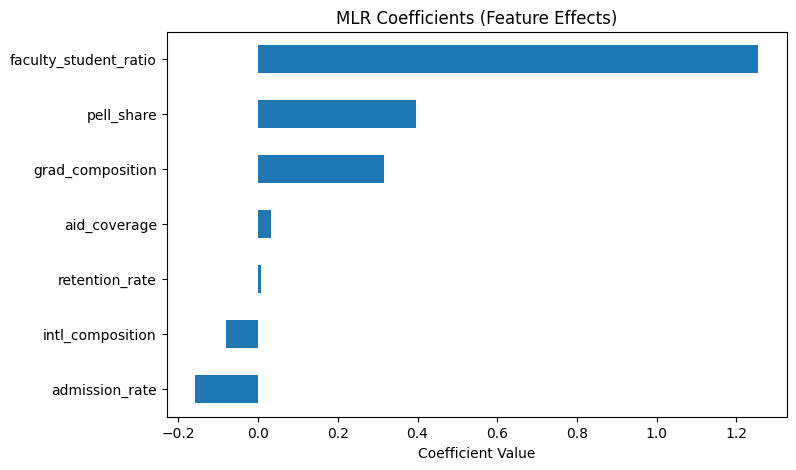

In [ ]:
#MLR Coefficient Plot
coef = pd.Series(mlr.coef_, index=features)

plt.figure(figsize=(8,5))
coef.sort_values().plot(kind="barh")
plt.title("MLR Coefficients (Feature Effects)")
plt.xlabel("Coefficient Value")
plt.show()

**6. Classification Model**

Yield rate is converted into a binary variable to classify institutions into high-yield and low-yield groups.

In [ ]:
class_df = model_df.copy()
threshold = class_df[target_variable].median()
class_df["yield_class"] = np.where(class_df[target_variable] >= threshold, 1, 0)

X_cls = class_df[features]
y_cls = class_df["yield_class"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

clf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

clf.fit(X_train_c, y_train_c)

y_pred_c = clf.predict(X_test_c)
y_prob_c = clf.predict_proba(X_test_c)[:, 1]

acc = accuracy_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)
auc = roc_auc_score(y_test_c, y_prob_c)
precision = precision_score(y_test_c, y_pred_c)
recall = recall_score(y_test_c, y_pred_c)

print("Classification Model Results")
print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Classification Model Results
Accuracy: 0.8727
F1-score: 0.8627
ROC-AUC: 0.8862
Precision: 0.9565
Recall: 0.7857


**6.1 Classification | Confusion Matrix**

In [ ]:
cm = confusion_matrix(y_test_c, y_pred_c)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[26  1]
 [ 6 22]]


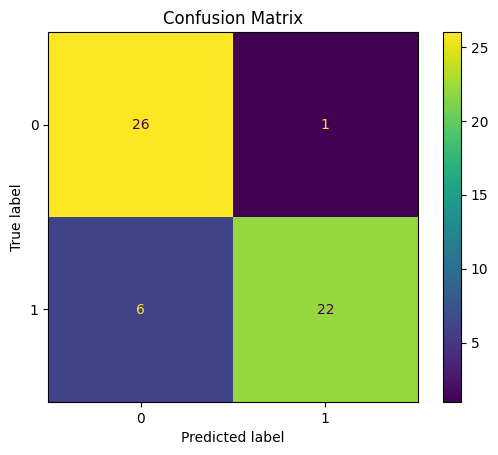

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(clf, X_test_c, y_test_c)
plt.title("Confusion Matrix")
plt.show()

**6.2 Classification | ROC Curve**

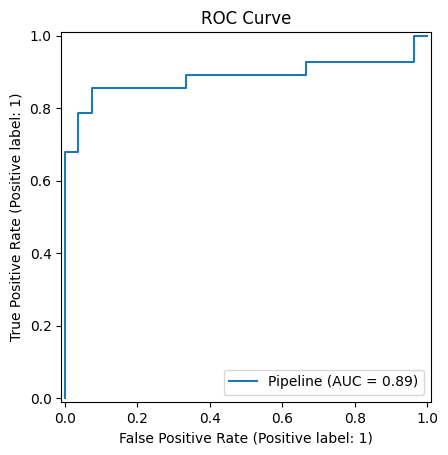

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(clf, X_test_c, y_test_c)
plt.title("ROC Curve")
plt.show()

In [ ]:
clf.named_steps["model"].coef_

array([[-0.9410391 , -0.57800717,  1.71251567,  0.7838993 ,  0.13576168,
         0.39819594,  1.02764602]])

**7. Lasso and Ridge Regression**

Lasso regression is used for coefficient shrinkage and feature selection.

Ridge regression is used to stabilise coefficient estimates and reduce the effect of multicollinearity.

In [ ]:
lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.01, max_iter=10000))
])

lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("Lasso Regression Results")
print(f"R²: {lasso_r2:.4f}")
print(f"RMSE: {lasso_rmse:.4f}")

Lasso Regression Results
R²: 0.6375
RMSE: 0.1140


In [ ]:
lasso_coef = lasso.named_steps["model"].coef_

print("Lasso Feature Selection")
for f, c in zip(features, lasso_coef):
    status = "Retained" if c != 0 else "Removed"
    print(f"{f}: {status}")

Lasso Feature Selection
admission_rate: Retained
intl_composition: Removed
faculty_student_ratio: Retained
grad_composition: Retained
aid_coverage: Removed
pell_share: Removed
retention_rate: Retained


In [ ]:
lasso.named_steps["model"].coef_

array([-0.04936846,  0.        ,  0.06847951,  0.02615211, -0.        ,
        0.        ,  0.020664  ])

In [ ]:
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("Ridge Regression Results")
print(f"R²: {ridge_r2:.4f}")
print(f"RMSE: {ridge_rmse:.4f}")

Ridge Regression Results
R²: 0.6673
RMSE: 0.1092


**7.1 Lasso and Ridge Coefficient**

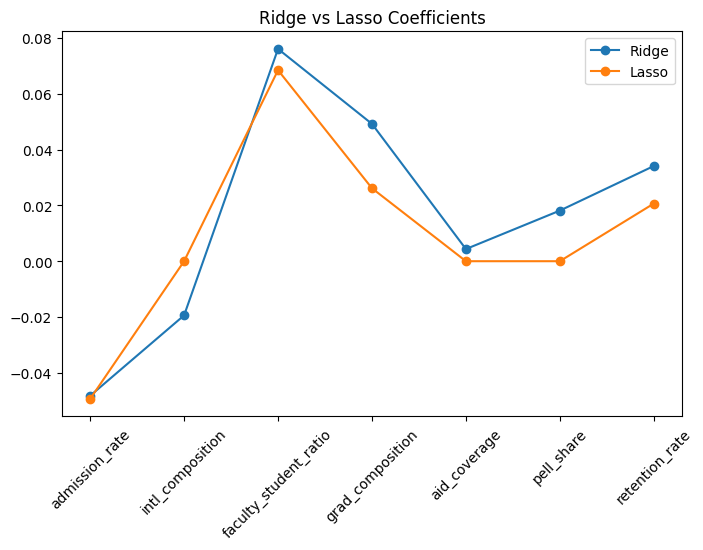

In [ ]:
ridge_coef = ridge.named_steps["model"].coef_
lasso_coef = lasso.named_steps["model"].coef_

plt.figure(figsize=(8,5))
plt.plot(features, ridge_coef, marker='o', label="Ridge")
plt.plot(features, lasso_coef, marker='o', label="Lasso")
plt.xticks(rotation=45)
plt.legend()
plt.title("Ridge vs Lasso Coefficients")
plt.show()

**8. Decision Tree**

The decision tree model is used to capture non-linear relationships and threshold effects.

In [ ]:
tree_depth4 = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_depth4.fit(X_train, y_train)

y_pred_tree_depth4 = tree_depth4.predict(X_test)

tree_depth4_r2 = r2_score(y_test, y_pred_tree_depth4)
tree_depth4_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tree_depth4))

print("Decision Tree Results")
print(f"R²: {tree_depth4_r2:.4f}")
print(f"RMSE: {tree_depth4_rmse:.4f}")

Decision Tree Results
R²: 0.5595
RMSE: 0.1257


In [ ]:
tree_depth3 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_depth3.fit(X_train, y_train)

y_pred_tree_depth3 = tree_depth3.predict(X_test)

tree_r2_depth3 = r2_score(y_test, y_pred_tree_depth3)
tree_rmse_depth3 = np.sqrt(mean_squared_error(y_test, y_pred_tree_depth3))

print("Decision Tree Results (max_depth=3)")
print(f"R²: {tree_r2_depth3:.4f}")
print(f"RMSE: {tree_rmse_depth3:.4f}")

Decision Tree Results (max_depth=3)
R²: 0.6844
RMSE: 0.1064


In [ ]:
tree_depth2 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_depth2.fit(X_train, y_train)

y_pred_tree_depth2 = tree_depth2.predict(X_test)

tree_r2_depth2 = r2_score(y_test, y_pred_tree_depth2)
tree_rmse_depth2 = np.sqrt(mean_squared_error(y_test, y_pred_tree_depth2))

print("Decision Tree Results (max_depth=2)")
print(f"R²: {tree_r2_depth2:.4f}")
print(f"RMSE: {tree_rmse_depth2:.4f}")

Decision Tree Results (max_depth=2)
R²: 0.7575
RMSE: 0.0932


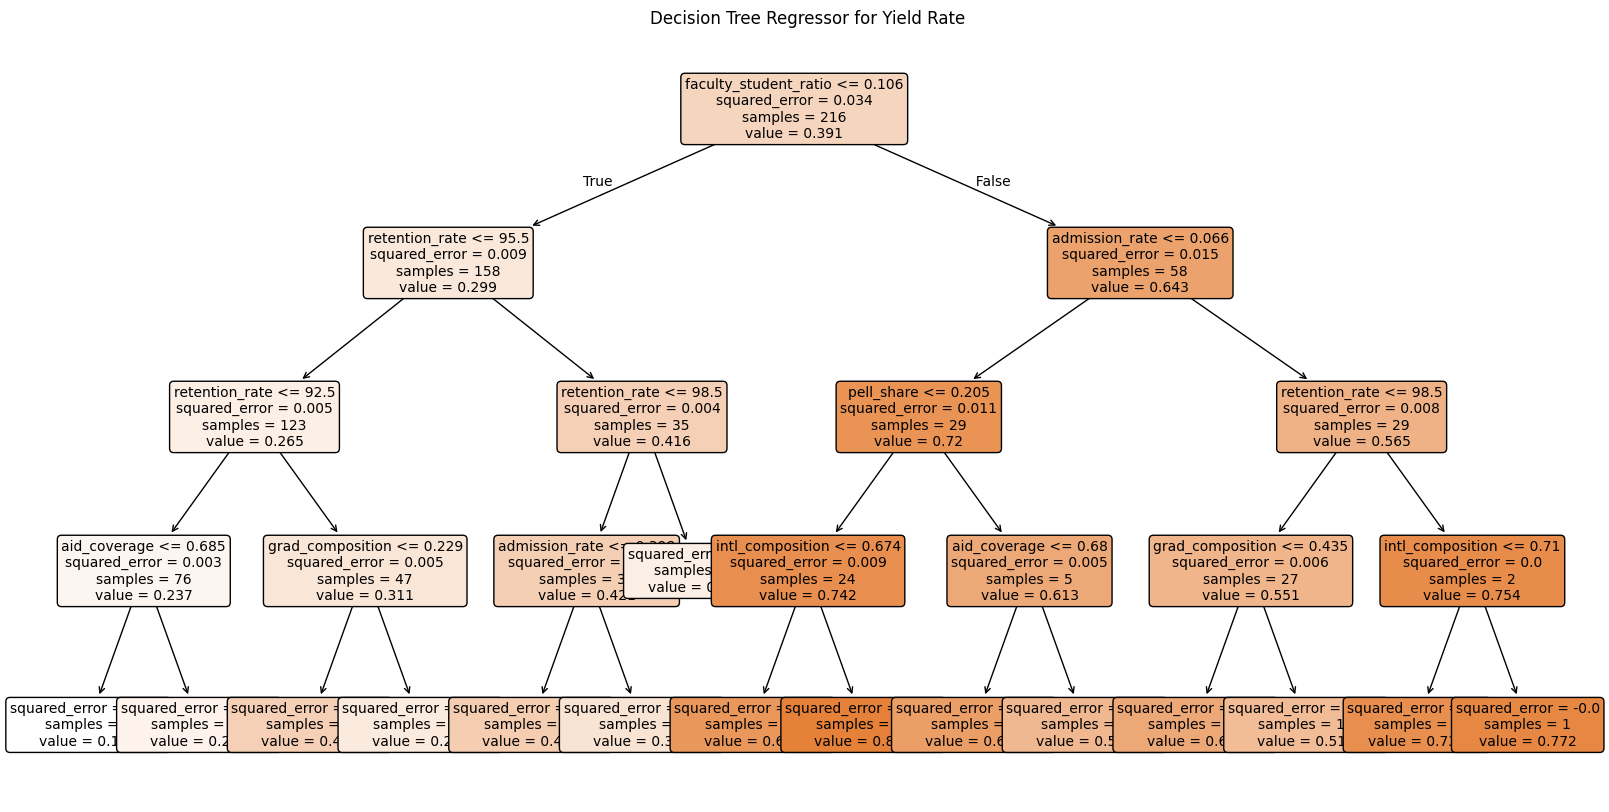

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(
    tree_depth4,
    feature_names=features,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Regressor for Yield Rate")
plt.show()

## Decision Tree Visualisation (max_depth=3)
This figure shows the simplified structure of the decision tree model with a maximum depth of 3.

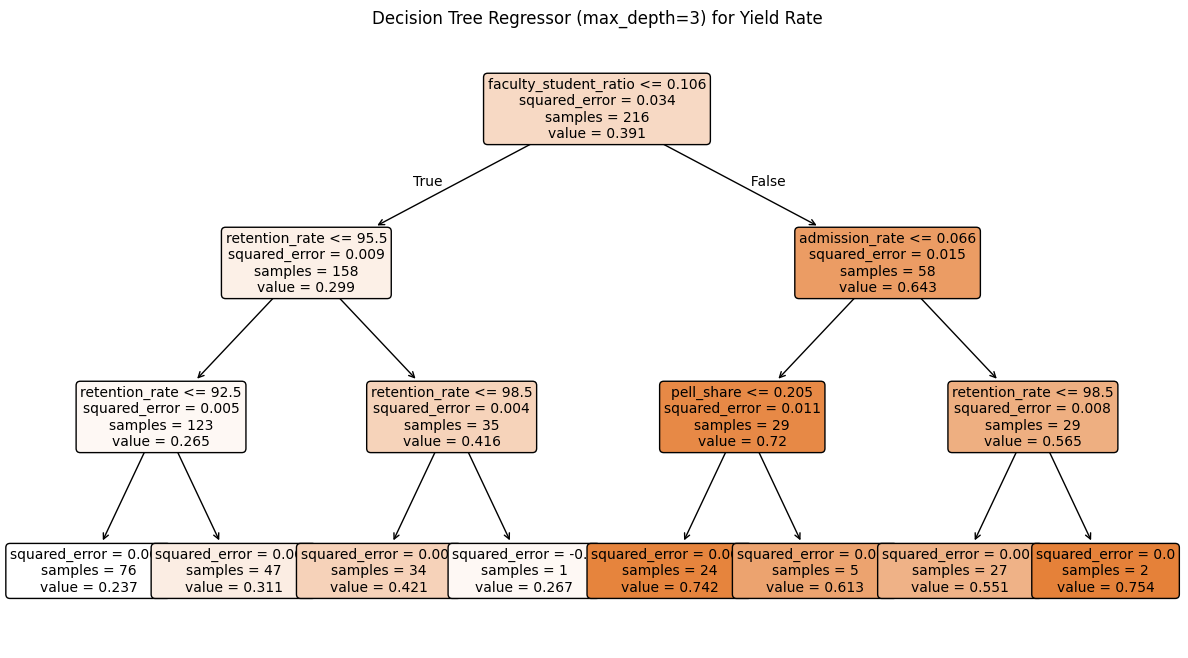

In [ ]:
plt.figure(figsize=(15, 8))
plot_tree(
    tree_depth3,
    feature_names=features,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Regressor (max_depth=3) for Yield Rate")
plt.show()

## Decision Tree Visualisation (max_depth=2)
This figure shows the simplified structure of the decision tree model with a maximum depth of 2.

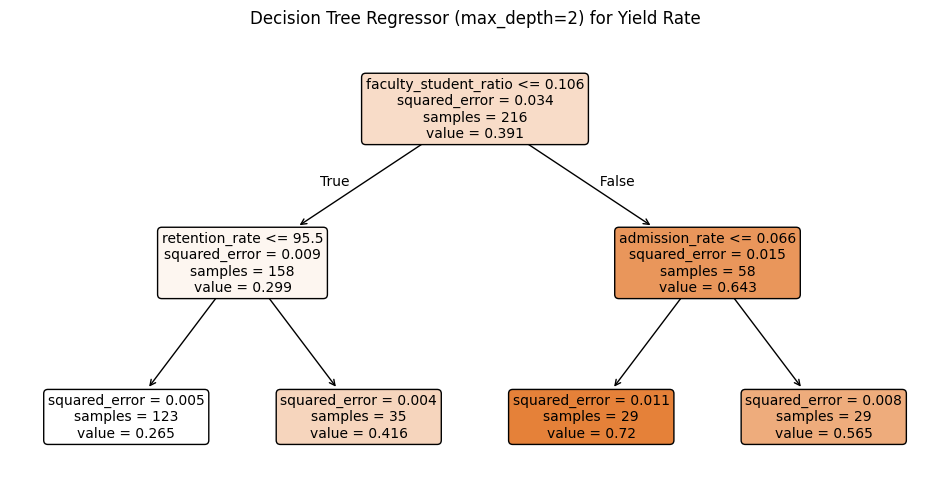

In [ ]:
plt.figure(figsize=(12, 6))
plot_tree(
    tree_depth2,
    feature_names=features,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Regressor (max_depth=2) for Yield Rate")
plt.show()

**9. Cross Validation**

In [ ]:
cv_scores = cross_val_score(tree, X, y, cv=5, scoring="r2")

print("Cross-validation R²:", round(cv_scores.mean(), 4))

Cross-validation R²: 0.6777


In [ ]:
tree_depth4.feature_importances_

array([0.05536118, 0.01086211, 0.75844282, 0.0251683 , 0.00711131,
       0.01050725, 0.13254704])

In [ ]:
tree_depth3.feature_importances_

array([0.05488546, 0.        , 0.79513881, 0.        , 0.        ,
       0.01101562, 0.1389601 ])

In [ ]:
tree_depth2.feature_importances_

array([0.05787309, 0.        , 0.83842129, 0.        , 0.        ,
       0.        , 0.10370562])

**10. Model Comparison**

In [ ]:
print("Final Model Comparison")
print(f"MLR -> R²: {mlr_r2:.4f}, RMSE: {mlr_rmse:.4f}")
print(f"Ridge -> R²: {ridge_r2:.4f}, RMSE: {ridge_rmse:.4f}")
print(f"Lasso -> R²: {lasso_r2:.4f}, RMSE: {lasso_rmse:.4f}")
print(f"Decision Tree (Depth 4) -> R²: {tree_depth4_r2:.4f}, RMSE: {tree_depth4_rmse:.4f}")
print(f"Decision Tree (Depth 2) -> R²: {tree_r2_depth2:.4f}, RMSE: {tree_rmse_depth2:.4f}")
print(f"Decision Tree (Depth 3) -> R²: {tree_r2_depth3:.4f}, RMSE: {tree_rmse_depth3:.4f}")
print(f"Classification -> Accuracy: {acc:.4f}, F1-score: {f1:.4f}, ROC-AUC: {auc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

Final Model Comparison
MLR -> R²: 0.6673, RMSE: 0.1092
Ridge -> R²: 0.6673, RMSE: 0.1092
Lasso -> R²: 0.6375, RMSE: 0.1140
Decision Tree (Depth 4) -> R²: 0.5595, RMSE: 0.1257
Decision Tree (Depth 2) -> R²: 0.7575, RMSE: 0.0932
Decision Tree (Depth 3) -> R²: 0.6844, RMSE: 0.1064
Classification -> Accuracy: 0.8727, F1-score: 0.8627, ROC-AUC: 0.8862, Precision: 0.9565, Recall: 0.7857


In [ ]:
from sklearn.model_selection import cross_val_score

for d in [2, 3, 4]:
    tree = DecisionTreeRegressor(max_depth=d, random_state=42)
    scores = cross_val_score(tree, X, y, cv=5, scoring="r2")

    print(f"Depth {d} CV R²: {scores.mean():.4f}")

Depth 2 CV R²: 0.6764
Depth 3 CV R²: 0.6551
Depth 4 CV R²: 0.6777
